Data loaded successfully!
Rows: 1684
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
              id  store_nbr     family   sales  onpromotion  is_open
date                                                                
2013-01-01     3          1  BEVERAGES     0.0            0    False
2013-01-02  1785          1  BEVERAGES  1091.0            0     True
2013-01-03  3567          1  BEVERAGES   919.0            0     True
2013-01-04  5349          1  BEVERAGES   953.0            0     True
2013-01-05  7131          1  BEVERAGES  1160.0            0     True
Train: 1347 rows
Test: 337 rows
WMAPE: 24.53%


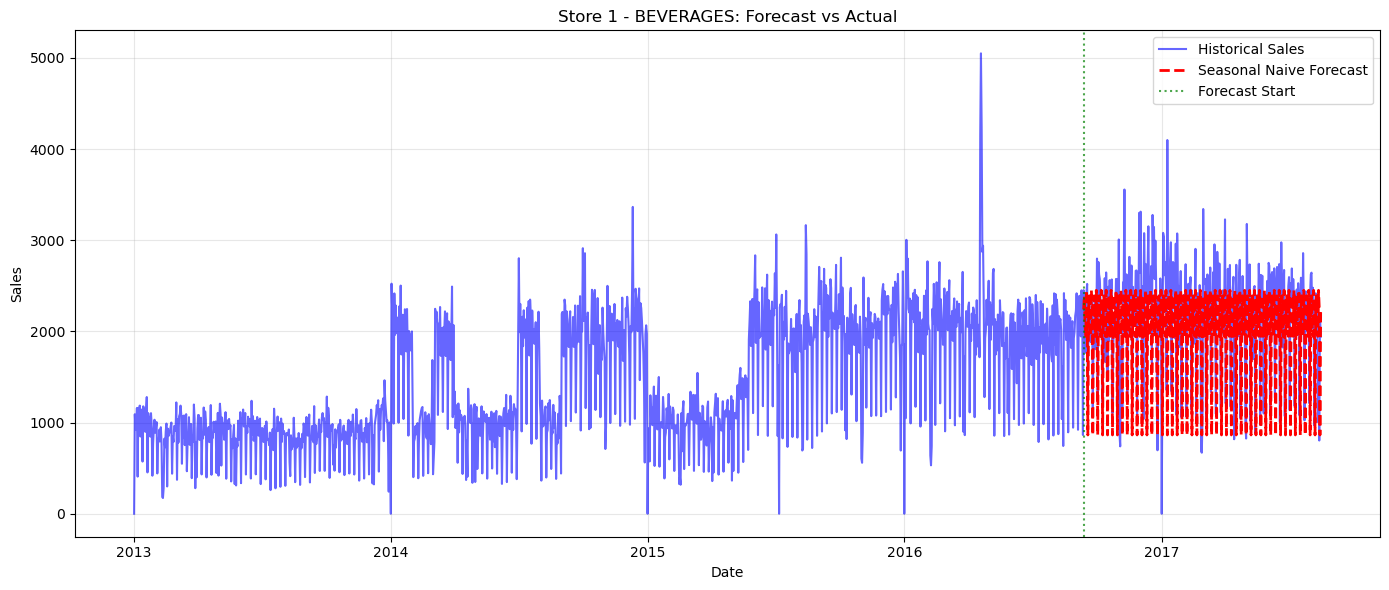

Plot saved as forecast_plot.png


In [1]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

# 2. LOAD AND PREPARE DATA
df = pd.read_csv('clean_sample.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df = df.set_index('date')

# 3. DATA SUMMARY
print("Data loaded successfully!")
print(f"Rows: {len(df)}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(df.head())

# 4. TRAIN-TEST SPLIT
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]
print(f"Train: {len(train)} rows")
print(f"Test: {len(test)} rows")

# 5. SEASONAL NAIVE MODEL
seasonal_period = 7
last_week = train['sales'].iloc[-seasonal_period:].values
predictions = np.tile(last_week, math.ceil(len(test) / seasonal_period))[:len(test)]

# Store predictions in test DataFrame for comparison
test = test.copy()
test['predicted'] = predictions

# 6. MODEL EVALUATION -Additional-
wmape = np.sum(np.abs(test['sales'] - test['predicted'])) / np.sum(np.abs(test['sales'])) * 100
print(f"WMAPE: {wmape:.2f}%")

# 7. VISUALIZATION
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['sales'], label='Historical Sales', color='blue', alpha=0.6)
plt.plot(test.index, test['predicted'], label='Seasonal Naive Forecast', 
         color='red', linestyle='--', linewidth=2)
plt.axvline(x=test.index[0], color='green', linestyle=':', alpha=0.7, 
            label='Forecast Start')
plt.title('Store 1 - BEVERAGES: Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_plot.png', dpi=300)
plt.show()

print("Plot saved as forecast_plot.png")